In [1]:
import re
import string
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

import gensim
import gensim.corpora as corpora
from gensim.models import CoherenceModel

import pyLDAvis
import pyLDAvis.gensim_models as gensimvis
from gensim.models import LdaModel, CoherenceModel


nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet') 

c:\Users\27726\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\27726\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\27726\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\27726\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\27726\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [2]:
df = pd.read_csv('C:\\Users\\27726\\Downloads\\articles.csv')

In [3]:
df['abstract'] = df['abstract'].fillna('')
df['title'] = df['title'].fillna('')


df = df.dropna(subset=['abstract', 'year'])
df['year'] = df['year'].astype(int)

df = df.drop_duplicates(subset=['title']).reset_index(drop=True)
print("Cleaned dataset shape:", df.shape)

Cleaned dataset shape: (6560, 7)


C:\Users\27726\AppData\Local\Temp\ipykernel_25708\2769355714.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=papers_per_year.index, y=papers_per_year.values, palette="Blues_d")


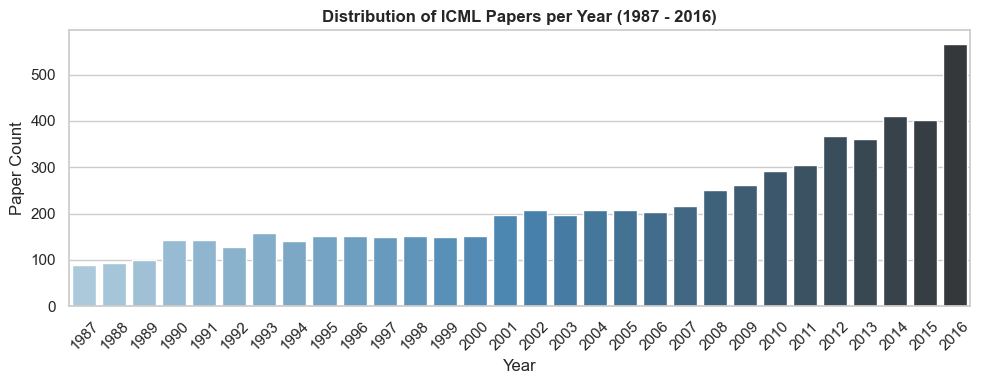

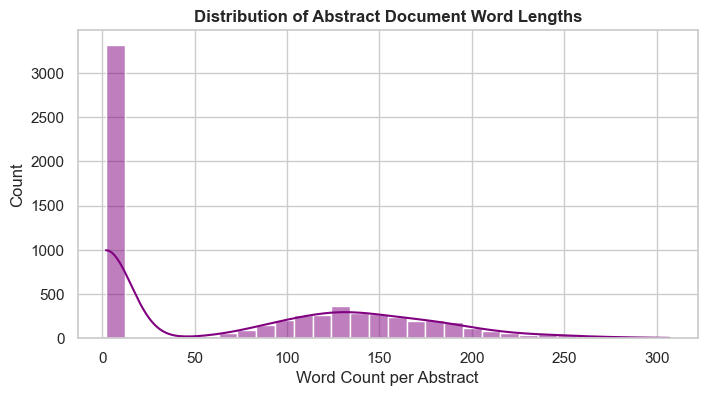

In [4]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 4))
papers_per_year = df['year'].value_counts().sort_index()
sns.barplot(x=papers_per_year.index, y=papers_per_year.values, palette="Blues_d")
plt.title("Distribution of ICML Papers per Year (1987 - 2016)", fontsize=12, fontweight='bold')
plt.xlabel("Year")
plt.ylabel("Paper Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


df['abstract_length'] = df['abstract'].apply(lambda x: len(str(x).split()))
plt.figure(figsize=(8, 4))
sns.histplot(df['abstract_length'], kde=True, color="purple", bins=30)
plt.title("Distribution of Abstract Document Word Lengths", fontsize=12, fontweight='bold')
plt.xlabel("Word Count per Abstract")
plt.show()

In [5]:
stop_words = set(stopwords.words('english'))
domain_specific_stops = {'paper', 'algorithm', 'method', 'approach', 'result', 'show', 'using', 'based', 'model', 'performance', 'data'}
stop_words.update(domain_specific_stops)

lemmatizer = WordNetLemmatizer()

def preprocess_academic_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text) 
    
    tokens = word_tokenize(text)
    
    
    cleaned_tokens = [
        lemmatizer.lemmatize(word) for word in tokens 
        if word not in stop_words and len(word) > 2 
    ]
    return cleaned_tokens

df['tokens'] = df['abstract'].apply(preprocess_academic_text)

dictionary = corpora.Dictionary(df['tokens'])

dictionary.filter_extremes(no_below=5, no_above=0.5)
corpus = [dictionary.doc2bow(text) for text in df['tokens']]

Running hyperparameter tuning iterations...
K=2 achieved a Coherence Score of: 0.6069
K=3 achieved a Coherence Score of: 0.6138
K=4 achieved a Coherence Score of: 0.6061
K=5 achieved a Coherence Score of: 0.6314
K=6 achieved a Coherence Score of: 0.6023
K=7 achieved a Coherence Score of: 0.5799
K=8 achieved a Coherence Score of: 0.5382
K=9 achieved a Coherence Score of: 0.5837
K=10 achieved a Coherence Score of: 0.5422


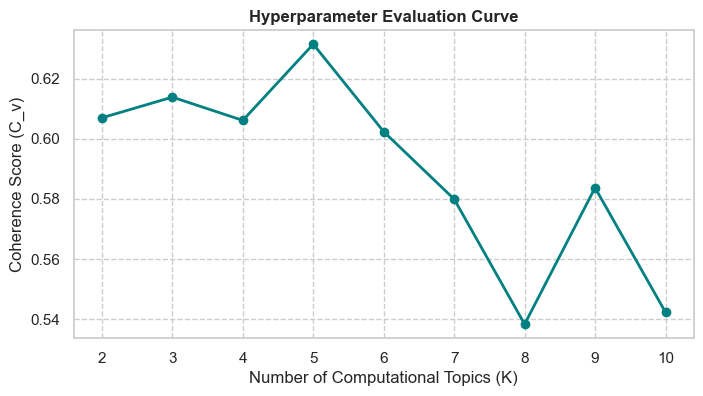

In [6]:
def compute_coherence(k):

    lda_model = LdaModel(corpus=corpus, id2word=dictionary, num_topics=k, random_state=42, passes=5)
    coherence_model = CoherenceModel(model=lda_model, texts=df['tokens'], dictionary=dictionary, coherence='c_v')
    return coherence_model.get_coherence()

k_values = range(2, 11)
coherence_scores = []

print("Running hyperparameter tuning iterations...")
for k in k_values:
    score = compute_coherence(k)
    coherence_scores.append(score)
    print(f"K={k} achieved a Coherence Score of: {score:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(k_values, coherence_scores, marker='o', color='teal', linewidth=2)
plt.xlabel("Number of Computational Topics (K)")
plt.ylabel("Coherence Score (C_v)")
plt.title("Hyperparameter Evaluation Curve", fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--')
plt.show()

In [7]:
optimal_k = 5 

final_lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=optimal_k,
    random_state=42,
    passes=20,          
    alpha='auto'        
)

print("\n--- Finalized Model Topic Key Vectors ---")
for idx, topic in final_lda_model.print_topics(num_topics=optimal_k, num_words=8):
    print(f"Topic {idx}: {topic}")


--- Finalized Model Topic Key Vectors ---
Topic 0: 0.015*"model" + 0.012*"learning" + 0.011*"inference" + 0.010*"problem" + 0.008*"graph" + 0.006*"method" + 0.006*"algorithm" + 0.006*"set"
Topic 1: 0.021*"function" + 0.020*"learning" + 0.015*"bound" + 0.013*"problem" + 0.010*"distribution" + 0.009*"loss" + 0.008*"kernel" + 0.007*"algorithm"
Topic 2: 0.028*"image" + 0.023*"network" + 0.016*"feature" + 0.014*"learning" + 0.013*"object" + 0.013*"training" + 0.013*"task" + 0.013*"deep"
Topic 3: 0.020*"problem" + 0.015*"matrix" + 0.010*"method" + 0.009*"algorithm" + 0.009*"optimization" + 0.009*"analysis" + 0.008*"sparse" + 0.007*"gradient"
Topic 4: 0.013*"network" + 0.013*"neural" + 0.009*"dynamic" + 0.009*"neuron" + 0.008*"system" + 0.008*"model" + 0.007*"process" + 0.007*"time"


In [8]:
pyLDAvis.enable_notebook()
vis_data = pyLDAvis.gensim_models.prepare(final_lda_model, corpus, dictionary, sort_topics=False)
vis_data

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0      0.006548  0.026337       1        1  28.666760
1      0.150901  0.028044       2        1  21.136716
2     -0.190112  0.123209       3        1  13.633525
3      0.131878  0.006057       4        1  21.919405
4     -0.099215 -0.183647       5        1  14.643593, topic_info=             Term         Freq        Total Category  logprob  loglift
277         image   949.000000   949.000000  Default  30.0000  30.0000
674       network  1419.000000  1419.000000  Default  29.0000  29.0000
23         matrix   798.000000   798.000000  Default  28.0000  28.0000
479         bound   910.000000   910.000000  Default  27.0000  27.0000
68         neural   793.000000   793.000000  Default  26.0000  26.0000
..            ...          ...          ...      ...      ...      ...
836      gaussian   145.248633   376.262931   Topic5  -5.5137   0.9693
66         linear   156.158527   693.172402   Topic5  -5.4413   0.4308
544         noise   126.857359   362.158283   Topic5  -5.6491   0.8721
113  distribution   145.896737  1055.141773   Topic5  -5.5093  -0.0574
11      different   126.779666   532.219525   Topic5  -5.6497   0.4866

[371 rows x 6 columns], token_table=      Topic      Freq         Term
term                              
3200      2  0.978979   achievable
320       5  0.994956     activity
2047      2  0.961830  advertising
1633      1  0.995147        agent
0         1  0.342716    algorithm
...     ...       ...          ...
636       1  0.394501         word
636       3  0.603354         word
1650      1  0.077472    worstcase
1650      2  0.903838    worstcase
1650      4  0.012912    worstcase

[700 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 2, 3, 4, 5])

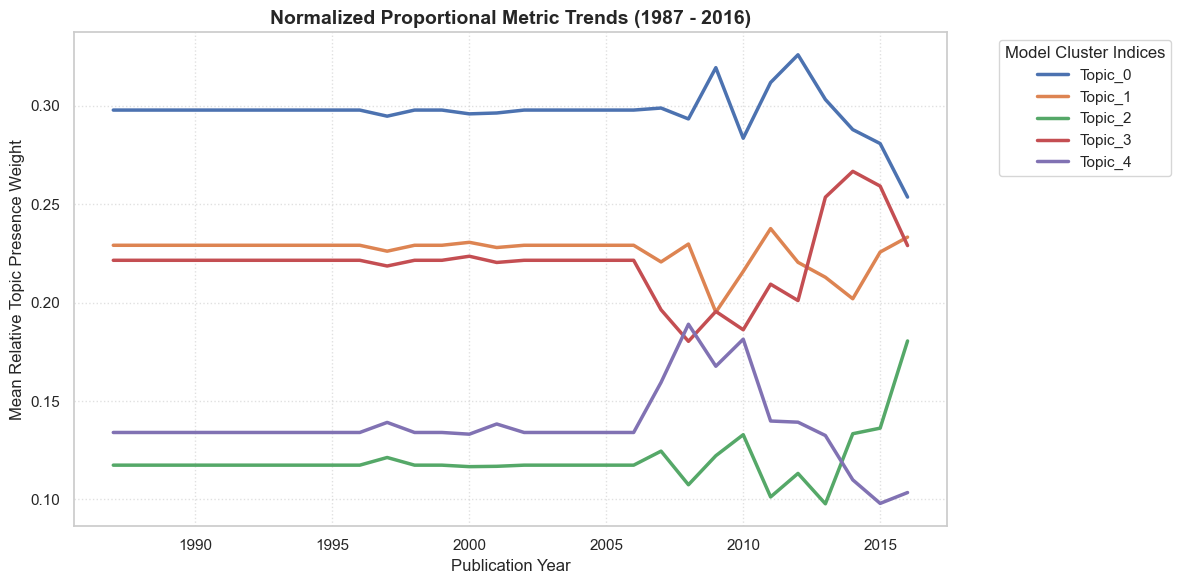

In [9]:
topic_weight_matrix = []
for bow in corpus:
    doc_weights = np.zeros(optimal_k)
    for topic_id, weight in final_lda_model.get_document_topics(bow, minimum_probability=0.0):
        doc_weights[topic_id] = weight
    topic_weight_matrix.append(doc_weights)

df_weights = pd.DataFrame(topic_weight_matrix, columns=[f'Topic_{i}' for i in range(optimal_k)])
df_weights['year'] = df['year']

yearly_trends = df_weights.groupby('year').mean()

plt.figure(figsize=(12, 6))
sns.lineplot(data=yearly_trends, dashes=False, linewidth=2.5)
plt.title("Normalized Proportional Metric Trends (1987 - 2016)", fontsize=14, fontweight='bold')
plt.xlabel("Publication Year")
plt.ylabel("Mean Relative Topic Presence Weight")
plt.legend(title="Model Cluster Indices", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()